In [1]:
import IJulia
import Base64

# The julia kernel has built in support for Revise.jl, so this is the 
# recommended approach for long-running sessions:
# https://github.com/JuliaLang/IJulia.jl/blob/9b10fa9b879574bbf720f5285029e07758e50a5e/src/kernel.jl#L46-L51

# Users should enable revise within .julia/config/startup_ijulia.jl:
# https://timholy.github.io/Revise.jl/stable/config/#Using-Revise-automatically-within-Jupyter/IJulia-1

# clear console history
IJulia.clear_history()

fig_width = 7
fig_height = 5
fig_format = :retina
fig_dpi = 96

# no retina format type, use svg for high quality type/marks
if fig_format == :retina
  fig_format = :svg
elseif fig_format == :pdf
  fig_dpi = 96
  # Enable PDF support for IJulia
  IJulia.register_mime(MIME("application/pdf"))
end

# convert inches to pixels
fig_width = fig_width * fig_dpi
fig_height = fig_height * fig_dpi

# Intialize Plots w/ default fig width/height
try
  import Plots

  # Plots.jl doesn't support PDF output for versions < 1.28.1
  # so use png (if the DPI remains the default of 300 then set to 96)
  if (Plots._current_plots_version < v"1.28.1") & (fig_format == :pdf)
    Plots.gr(size=(fig_width, fig_height), fmt = :png, dpi = fig_dpi)
  else
    Plots.gr(size=(fig_width, fig_height), fmt = fig_format, dpi = fig_dpi)
  end
catch e
  # @warn "Plots init" exception=(e, catch_backtrace())
end

# Initialize CairoMakie with default fig width/height
try
  import CairoMakie

  # CairoMakie's display() in PDF format opens an interactive window
  # instead of saving to the ipynb file, so we don't do that.
  # https://github.com/quarto-dev/quarto-cli/issues/7548
  if fig_format == :pdf
    CairoMakie.activate!(type = "png")
  else
    CairoMakie.activate!(type = string(fig_format))
  end
  CairoMakie.update_theme!(resolution=(fig_width, fig_height))
catch e
    # @warn "CairoMakie init" exception=(e, catch_backtrace())
end
  
# Set run_path if specified
try
  run_path = "QzpcVXNlcnNcTmlrb2xhalxHaXRcZ3JhcGgtZXF1aWxpYnJpdW0tcmFkaWF0aXZlLXRyYW5zZmVyXGV4YW1wbGVz"
  if !isempty(run_path)
    run_path = String(Base64.base64decode(run_path))
    cd(run_path)
  end
catch e
  @warn "Run path init:" exception=(e, catch_backtrace())
end


# emulate old Pkg.installed beahvior, see
# https://discourse.julialang.org/t/how-to-use-pkg-dependencies-instead-of-pkg-installed/36416/9
import Pkg
function isinstalled(pkg::String)
  any(x -> x.name == pkg && x.is_direct_dep, values(Pkg.dependencies()))
end

# ojs_define
if isinstalled("JSON") && isinstalled("DataFrames")
  import JSON, DataFrames
  global function ojs_define(; kwargs...)
    convert(x) = x
    convert(x::DataFrames.AbstractDataFrame) = Tables.rows(x)
    content = Dict("contents" => [Dict("name" => k, "value" => convert(v)) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
elseif isinstalled("JSON")
  import JSON
  global function ojs_define(; kwargs...)
    content = Dict("contents" => [Dict("name" => k, "value" => v) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
else
  global function ojs_define(; kwargs...)
    @warn "JSON package not available. Please install the JSON.jl package to use ojs_define."
  end
end


# don't return kernel dependencies (b/c Revise should take care of dependencies)
nothing


In [2]:
using RayTraceHeatTransfer
using GeometryBasics, StaticArrays, Random
include(joinpath(pkgdir(RayTraceHeatTransfer), "examples", "lbl_slab_reference.jl"))

T1, T2 = 1000.0, 500.0                        # hot and cold plate temperatures [K]
NX = 32                                       # number of cells across the slab

# wavelength grid: 200 001 points, logarithmically spaced from 10 nm to 1 cm
λ = 10 .^ range(log10(1e-8), log10(1e-2), length = 200_001)

# 400 synthetic absorption lines with random centre, width and strength (fixed seed: reproducible)
lines = let rng = MersenneTwister(1)
    centres = 10 .^ (log10(1.5e-6) .+ (log10(30e-6) - log10(1.5e-6)) .* rand(rng, 400))   # 1.5–30 μm, uniform in log λ
    peaks   = 10 .^ (log10(0.1) .+ 5.0 .* rand(rng, 400))                                  # peak strengths over five decades
    widths  = 1e-4 .+ 2e-4 .* rand(rng, 400)                                               # half-widths, in decades of λ
    collect(zip(centres, widths, peaks))                                                   # one (centre, half-width, peak) per line
end

# Absorption coefficient [1/m] at wavelength x: a weak continuum plus the sum of all lines.
# Each line is a Lorentzian in log₁₀ λ: peak / (1 + (distance from the centre / half-width)²).
function absorption(x)
    line_sum = 0.0
    for (centre, half_width, peak) in lines
        distance = log10(x / centre)                       # distance from the line centre, in decades of λ
        line_sum += peak / (1 + (distance / half_width)^2)
    end
    return 0.1 * (1e-3 + line_sum)                         # continuum 1e-3, overall scale 0.1
end
κ = [absorption(x) for x in λ]

T_lbl, q_lbl, _ = lbl_slab_equilibrium(λ, κ, 1.0, T1, T2; Nx = NX)   # line-by-line reference, slab thickness 1 m
ψ_lbl = q_lbl / (LBL_σ * (T1^4 - T2^4))       # net flux, normalised by the black-plate exchange

0.49717948889894925

In [3]:
model = adaptiveSpectralBins(λ, κ; tol = 1e-2, L_range = (1 / NX, 3.0), T_range = (T2, T1))
K = length(model.κ_ref)                       # number of bins

20

In [4]:
W, NX_H = 100_000.0, 5                        # cavity width [m] and number of columns of cells
verts = SVector(Point2(0.0, 0.0), Point2(W, 0.0), Point2(W, 1.0), Point2(0.0, 1.0))   # corners, counter-clockwise
face  = PolyVolume2D{Float64}(verts, SVector(true, true, true, true), K, 1.0, 0.0)    # four solid walls, K spectral bins
face.kappa_g   = copy(model.κ_ref)            # absorption coefficient of every bin [1/m]
face.sigma_s_g = zeros(K)                     # no scattering
face.epsilon   = [fill(1.0, K), fill(1.0, K), fill(1.0, K), fill(1.0, K)]   # black in every bin; wall order: bottom, right, top, left
face.T_in_w    = [T1, 0.0, T2, 0.0]           # wall temperatures [K]: bottom T1, top T2, sides at 0 K
face.q_in_w    = zeros(4)                     # wall sources, not used when the temperature is prescribed
face.T_in_g    = -1.0                         # negative: the gas temperature is unknown ...
face.q_in_g    = 0.0                          # ... and its net source is zero, i.e. radiative equilibrium

mesh = RayTracingDomain2D([face], [(NX_H, NX)]; verbose = false)   # 5 columns × 32 rows of cells
mesh.spectral_model = model;

In [5]:
mesh(10^7; method = :pathlength, chunk_rays = 10^7, verbose = false)  # one chunk: paths kept, re-binnable via `exchangeFactors!(mesh)`
smooth!(mesh; k_dykstra = 200, k_ap = 10^4, verbose = false)          # smoothing: 200 Dykstra rounds, ≤ 10⁴ alternating projections
solveEquilibrium!(mesh, mesh.F_smooth; max_iters = 20_000, convergence_tol = 1e-12, verbose = false)

# The side walls disturb the columns next to them; the centre column of the wide
# cavity is the 1D slab solution.
i_centre = (NX_H + 1) ÷ 2                                   # index of the centre column (3 of 5)
x_centre = (i_centre - 0.5) * W / NX_H                      # x-coordinate of its cell centres
centre_cells = [cell for cell in mesh.fine_mesh[1]          # all cells of the first (and only) coarse face ...
                if abs(cell.midPoint[1] - x_centre) < 1e-9 * W]   # ... whose centre lies in that column
sort!(centre_cells, by = cell -> cell.midPoint[2])          # order them from the hot plate (y = 0) upwards

T_pkg = [cell.T_g for cell in centre_cells]                 # T_g: gas temperature written by the solver

bottom = centre_cells[1]                                    # the cell touching the hot plate
# wall 1 of a cell is its bottom edge; q_w is that wall's net radiative power [W], area its length [m]
ψ_pkg = (bottom.q_w[1] / bottom.area[1]) / (LBL_σ * (T1^4 - T2^4))   # net flux, normalised

0.4973067512322223

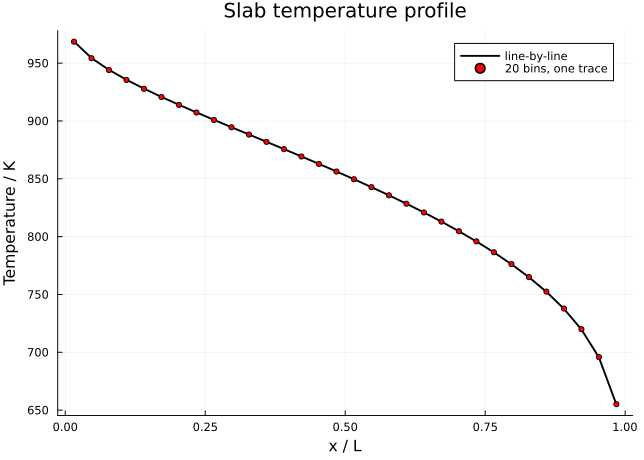

In [6]:
using Plots

# The model cuts the wavelength axis into pieces at `model.edges`; piece p belongs to bin `model.piece_bin[p]`.
# For every wavelength sample: find the piece it falls in, then look up that piece's bin.
n_spectral = length(model.piece_bin)
piece = clamp.(searchsortedlast.(Ref(model.edges), λ), 1, n_spectral)  # index of the last edge ≤ λ, kept within 1:n_spectral
bin   = model.piece_bin[piece]                                         # bin index of every wavelength sample
sel   = 1e-6 .<= λ .<= 1e-4                                            # plot 1–100 μm only, where the lines are

p1 = Plots.plot(λ[sel] .* 1e6, κ[sel]; line_z = bin[sel], color = :turbo, linewidth = 1,
    xscale = :log10, yscale = :log10, xlabel = "Wavelength / μm", ylabel = "κ / m⁻¹",
    colorbar_title = "bin", legend = false, title = "Spectrum coloured by adaptive bin")

x_c = ((1:NX) .- 0.5) ./ NX
p2 = Plots.plot(x_c, T_lbl; linewidth = 2, color = :black, label = "line-by-line",
    xlabel = "x / L", ylabel = "Temperature / K", title = "Slab temperature profile")
Plots.scatter!(p2, x_c, T_pkg; color = :red, markersize = 3, label = "$K bins, one trace")

In [7]:
println("max |T − T_LBL| = ", round(maximum(abs.(T_pkg .- T_lbl)); digits = 2), " K,  ",
        "ψ − ψ_LBL = ", round(ψ_pkg - ψ_lbl; sigdigits = 2))

max |T − T_LBL| = 0.3 K,  ψ − ψ_LBL = 0.00013


In [8]:
#| eval: false
model2 = adaptiveSpectralBins(λ, κ; tol = 1e-3, L_range = (1 / NX, 3.0), T_range = (T2, T1))
K2 = length(model2.κ_ref)                       # 31 bins

# the number of spectral bins is fixed when a face is built, so the tighter model needs a new face ...
face2 = PolyVolume2D{Float64}(verts, SVector(true, true, true, true), K2, 1.0, 0.0)
face2.kappa_g   = copy(model2.κ_ref)            # one absorption coefficient per bin
face2.sigma_s_g = zeros(K2)                     # no scattering
face2.epsilon   = [fill(1.0, K2), fill(1.0, K2), fill(1.0, K2), fill(1.0, K2)]
face2.T_in_w    = [T1, 0.0, T2, 0.0]            # same boundary conditions as before
face2.q_in_w    = zeros(4)
face2.T_in_g    = -1.0
face2.q_in_g    = 0.0

# ... and a new mesh with the same subdivision, hence the same element numbering
mesh2 = RayTracingDomain2D([face2], [(NX_H, NX)])
mesh2.spectral_model = model2
mesh2.path_store = mesh.path_store              # take over the recorded paths: they are geometry only
exchangeFactors!(mesh2)                         # F_raw for the 31 bins, without tracing again